=== Path Check ===
  OK      S1Hand                     → /kaggle/input/datasets/smabrarrajin/sen1floods11-essentials/v1.2/data/flood_events/HandLabeled/S1Hand
  OK      LabelHand                  → /kaggle/input/datasets/smabrarrajin/sen1floods11-essentials/v1.2/data/flood_events/HandLabeled/LabelHand
  MISSING Weak S1 (unlabeled pool)   → None
  MISSING Weak label masks           → None

Deriving image-level labels from masks (flooded = water fraction ≥ 0.01) ...
  Chips: 441  (293 flooded | 148 non-flooded)

=== Training Sets ===
  Supervised-only  : 176 chips  (122 flooded | 54 non-flooded)
  Full-supervision : 352 chips  (234 flooded | 118 non-flooded)
  Val              : 89 chips

Device  : cuda
GPU     : Tesla T4
Pruning : unstructured [0.3, 0.5, 0.7, 0.9] | structured [0.2, 0.4, 0.6] | fine-tune 10 ep each

════════════════════════════════════════════════════════════════════════
  BACKBONE PROFILE — parameters & FLOPs @ 3×224×224, batch=1
══════════════════════════════════════

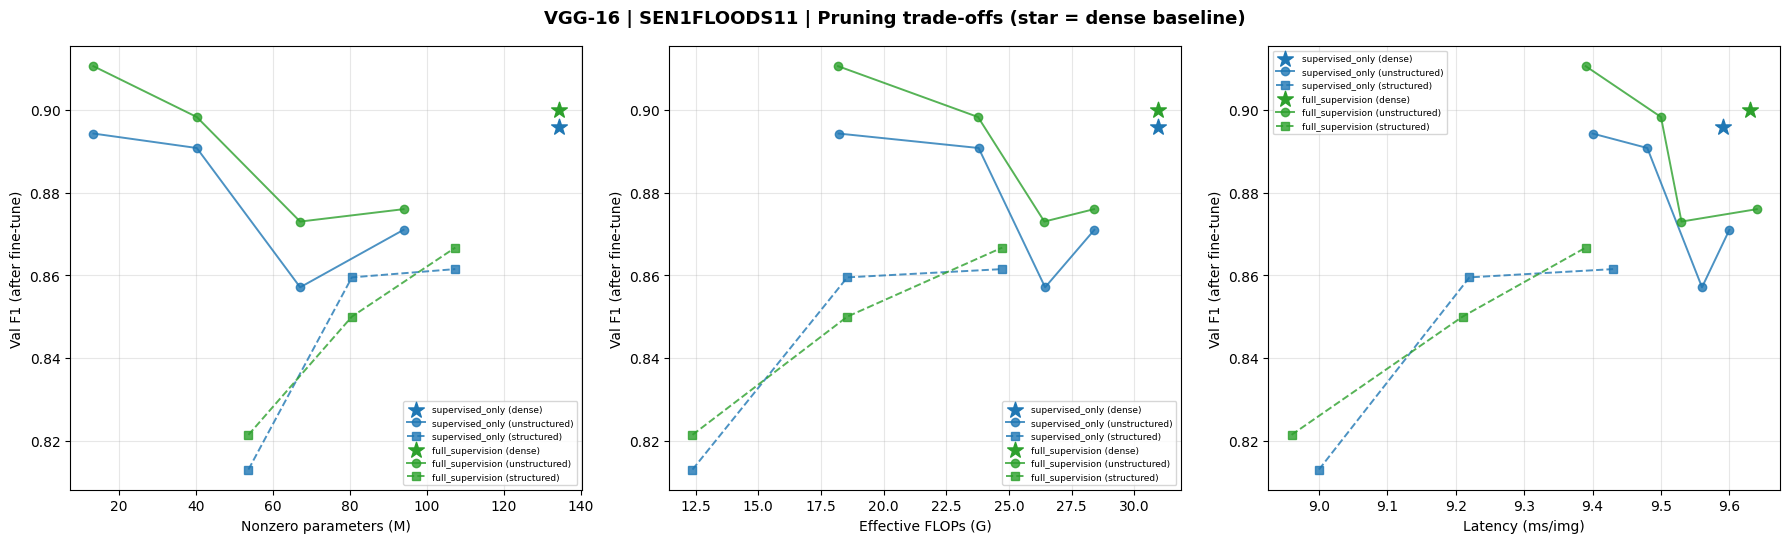

Saved → vgg16_sen1floods11_pruning_tradeoff.png


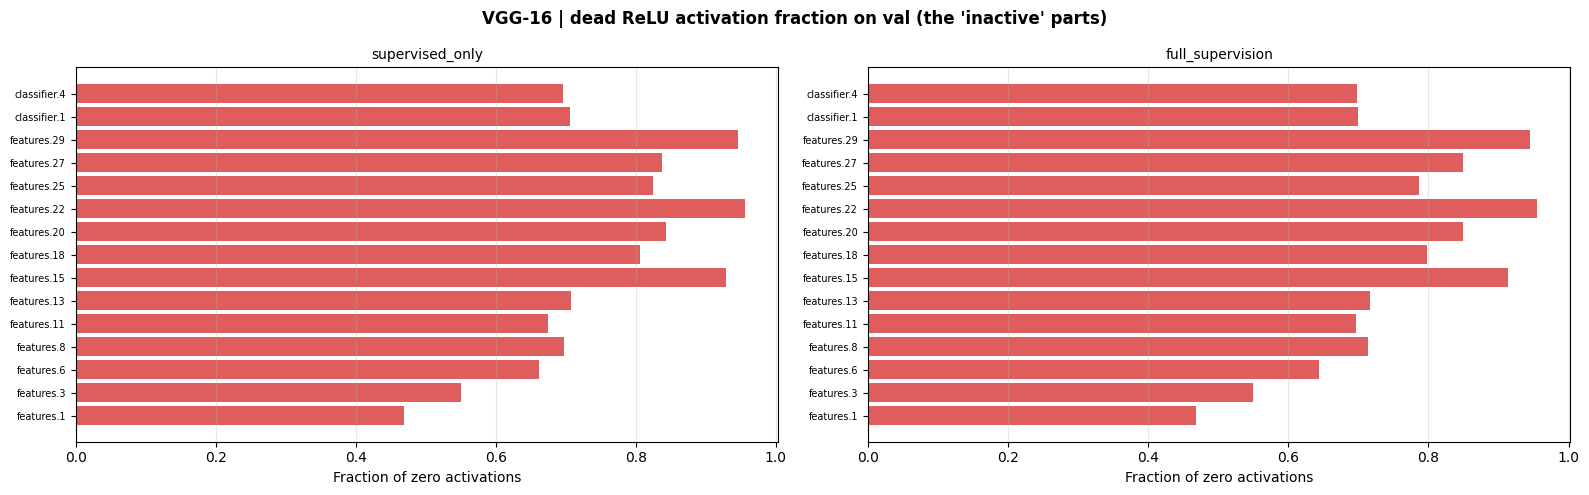

Saved → vgg16_sen1floods11_dead_activations.png

✓ All done.


In [4]:
import os, copy, random, time, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from pathlib import Path
import rasterio
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.nn.utils.prune as prune
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from torchvision.models import VGG16_Weights
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
)
import matplotlib.pyplot as plt

SEED = 2024
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

# ── 1. PATHS — auto-detect the dataset layout ──────────────────────────
ROOT = Path("/kaggle/input/sen1floods11-essentials")
if not ROOT.exists():
    import kagglehub
    ROOT = Path(kagglehub.dataset_download("smabrarrajin/sen1floods11-essentials"))

def find_dir(root, target_name):
    """Walk directories only (cheap) and return the first match by name."""
    for dirpath, dirnames, _ in os.walk(root):
        for d in dirnames:
            if d.lower() == target_name.lower():
                return Path(dirpath) / d
    return None

S1_DIR        = find_dir(ROOT, "S1Hand")
LABEL_DIR     = find_dir(ROOT, "LabelHand")
WEAK_DIR      = find_dir(ROOT, "S1Weak")            # weakly-labeled S1 chips
WEAK_LBL_DIR  = (find_dir(ROOT, "S1OtsuLabelWeak")  # weak reference masks
                 or find_dir(ROOT, "S2IndexLabelWeak"))

print("=== Path Check ===")
for name, p in [("S1Hand", S1_DIR), ("LabelHand", LABEL_DIR),
                ("Weak S1 (unlabeled pool)", WEAK_DIR),
                ("Weak label masks", WEAK_LBL_DIR)]:
    print(f"  {'OK' if p else 'MISSING':7} {name:<26} → {p}")
assert S1_DIR is not None and LABEL_DIR is not None, \
    "Could not locate S1Hand / LabelHand folders — check dataset root."

# ── 2. Derive image-level labels from pixel masks ──────────────────────
#  (identical constants and RNG call order to the baseline script
#   → chip-for-chip identical splits)
FLOOD_THRESHOLD    = 0.01   # chip = flooded if ≥1% of valid pixels are water
UNLABELED_FRACTION = 0.50   # fallback only (when no weak S1 folder exists)
MAX_UNLABELED      = 1500   # cap unlabeled pool (RAM guard)

def water_fraction(mask_path):
    """Fraction of VALID pixels (mask != -1) that are water (mask == 1)."""
    with rasterio.open(mask_path) as src:
        m = src.read(1)
    valid = m != -1
    if not valid.any():
        return None
    return float((m[valid] == 1).mean())

print("\nDeriving image-level labels from masks "
      f"(flooded = water fraction ≥ {FLOOD_THRESHOLD:.2f}) ...")

all_samples = []                      # (s1_path, label)
for mask_path in sorted(LABEL_DIR.glob("*.tif")):
    stem    = mask_path.name.replace("_LabelHand.tif", "")
    s1_path = S1_DIR / f"{stem}_S1Hand.tif"
    if not s1_path.exists():
        continue
    wf = water_fraction(mask_path)
    if wf is None:                    # chip is entirely no-data
        continue
    all_samples.append((str(s1_path), int(wf >= FLOOD_THRESHOLD)))

flooded_s    = [s for s in all_samples if s[1] == 1]
nonflooded_s = [s for s in all_samples if s[1] == 0]
print(f"  Chips: {len(all_samples)}  "
      f"({len(flooded_s)} flooded | {len(nonflooded_s)} non-flooded)")

# ── 3. 80/20 labeled split (same RNG order as before) ──────────────────
random.shuffle(flooded_s)
random.shuffle(nonflooded_s)

def split80(lst):
    cut = int(0.8 * len(lst))
    return lst[:cut], lst[cut:]

f_train,  f_val  = split80(flooded_s)
nf_train, nf_val = split80(nonflooded_s)

TRAIN_SAMPLES = f_train + nf_train
VAL_SAMPLES   = f_val   + nf_val

# ── 4. Unlabeled pool (same RNG order as before) ───────────────────────
if WEAK_DIR is not None:
    UNLABELED_PATHS = [str(p) for p in sorted(WEAK_DIR.glob("*.tif"))]
    random.shuffle(UNLABELED_PATHS)
    UNLABELED_PATHS = UNLABELED_PATHS[:MAX_UNLABELED]
else:
    random.shuffle(TRAIN_SAMPLES)
    cut             = int((1 - UNLABELED_FRACTION) * len(TRAIN_SAMPLES))
    UNLABELED_PATHS = [p for p, _ in TRAIN_SAMPLES[cut:]]
    HIDDEN_TRUE     = {p: l for p, l in TRAIN_SAMPLES[cut:]}
    TRAIN_SAMPLES   = TRAIN_SAMPLES[:cut]

UNLABELED_TRUE = {}
if WEAK_DIR is None:
    UNLABELED_TRUE = HIDDEN_TRUE
elif WEAK_LBL_DIR is not None:
    weak_suffix = f"_{WEAK_LBL_DIR.name}.tif"
    s1w_suffix  = f"_{WEAK_DIR.name}.tif"
    for p in UNLABELED_PATHS:
        stem = Path(p).name.replace(s1w_suffix, "")
        wm   = WEAK_LBL_DIR / f"{stem}{weak_suffix}"
        if not wm.exists():
            continue
        wf = water_fraction(wm)
        if wf is not None:
            UNLABELED_TRUE[p] = int(wf >= FLOOD_THRESHOLD)

# ── 5. The two baseline training sets ──────────────────────────────────
SUPERVISED_ONLY_SET  = list(TRAIN_SAMPLES)
FULL_SUPERVISION_SET = list(TRAIN_SAMPLES) + \
    [(p, UNLABELED_TRUE[p]) for p in UNLABELED_PATHS if p in UNLABELED_TRUE]

def class_counts(samples):
    f  = sum(1 for _, l in samples if l == 1)
    nf = sum(1 for _, l in samples if l == 0)
    return f, nf

print(f"\n=== Training Sets ===")
for name, s in [("Supervised-only", SUPERVISED_ONLY_SET),
                ("Full-supervision", FULL_SUPERVISION_SET)]:
    f, nf = class_counts(s)
    print(f"  {name:<17}: {len(s)} chips  ({f} flooded | {nf} non-flooded)")
print(f"  Val              : {len(VAL_SAMPLES)} chips")

# ── 6. Hyper-parameters ────────────────────────────────────────────────
IMG_SIZE  = 224
BATCH     = 16
LR        = 1e-4
E         = 50      # full baseline training (only if no .pth found)
FT_EPOCHS = 10      # fine-tuning epochs after each pruning step
DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")

UNSTRUCTURED_LEVELS = [0.30, 0.50, 0.70, 0.90]   # global sparsity targets
STRUCTURED_LEVELS   = [0.20, 0.40, 0.60]          # filter/neuron ratios

print(f"\nDevice  : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
print(f"Pruning : unstructured {UNSTRUCTURED_LEVELS} | "
      f"structured {STRUCTURED_LEVELS} | fine-tune {FT_EPOCHS} ep each")

# ── 7. SAR chip loading → 3-channel tensor (identical) ─────────────────
DB_MIN, DB_MAX = -50.0, 1.0
IMAGENET_MEAN  = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD   = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def load_s1_tensor(path):
    """2-band SAR GeoTIFF → normalized 3×224×224 float tensor."""
    with rasterio.open(path) as src:
        arr = src.read().astype(np.float32)
    arr = np.nan_to_num(arr, nan=DB_MIN)
    arr = np.clip(arr, DB_MIN, DB_MAX)
    arr = (arr - DB_MIN) / (DB_MAX - DB_MIN)
    vv, vh = arr[0], arr[1]
    img = np.stack([vv, vh, (vv + vh) / 2.0])
    t = torch.from_numpy(img)
    t = F.interpolate(t.unsqueeze(0), size=(IMG_SIZE, IMG_SIZE),
                      mode="bilinear", align_corners=False).squeeze(0)
    return (t - IMAGENET_MEAN) / IMAGENET_STD

class LabeledDS(Dataset):
    def __init__(self, samples):
        self.samples = samples
    def __len__(self): return len(self.samples)
    def __getitem__(self, i):
        path, lbl = self.samples[i]
        return load_s1_tensor(path), torch.tensor(lbl, dtype=torch.float32)

val_ldr = DataLoader(LabeledDS(VAL_SAMPLES), batch_size=BATCH,
                     shuffle=False, num_workers=2, pin_memory=True)

def make_train_loader(samples):
    f, nf = class_counts(samples)
    n     = len(samples)
    cw    = [n/(2*nf), n/(2*f)]
    sw    = [cw[int(l)] for _, l in samples]
    sampler = WeightedRandomSampler(sw, len(sw), replacement=True)
    return DataLoader(LabeledDS(samples), batch_size=BATCH, sampler=sampler,
                      num_workers=2, pin_memory=True)

# ── 8. Model builders (weights=None → profiling only, no download) ─────
def build_vgg16(pretrained=True):
    w = VGG16_Weights.IMAGENET1K_V1 if pretrained else None
    m = models.vgg16(weights=w)
    m.classifier[-1] = nn.Linear(4096, 1)   # 4096 → 1
    return m

def build_backbone_for_profile(name):
    if name == "resnet18":
        m = models.resnet18(weights=None); m.fc = nn.Linear(512, 1)
    elif name == "vgg16":
        m = models.vgg16(weights=None); m.classifier[-1] = nn.Linear(4096, 1)
    elif name == "mobilenet_v2":
        m = models.mobilenet_v2(weights=None)
        m.classifier = nn.Sequential(nn.Dropout(0.2),
                                     nn.Linear(m.last_channel, 1))
    elif name == "shufflenet_v2":
        m = models.shufflenet_v2_x1_0(weights=None)
        m.fc = nn.Linear(m.fc.in_features, 1)
    return m

# ── 9. Params & FLOPs profiler (hook-based, no dependencies) ───────────
def profile_model(model, img_size=224):
    """Count parameters and MACs/FLOPs for one forward pass (batch=1).
    MACs counted for Conv2d and Linear (they dominate); FLOPs ≈ 2×MACs."""
    model = model.to("cpu").eval()
    macs_total = {"v": 0}
    per_layer  = {}   # name -> macs, for effective-FLOPs calc
    hooks = []

    def conv_hook(name):
        def fn(mod, inp, out):
            out_elems = out.numel()                      # B×Cout×H×W
            k = mod.kernel_size[0] * mod.kernel_size[1]
            macs = out_elems * (mod.in_channels // mod.groups) * k
            macs_total["v"] += macs
            per_layer[name] = macs
        return fn

    def lin_hook(name):
        def fn(mod, inp, out):
            macs = mod.in_features * mod.out_features
            macs_total["v"] += macs
            per_layer[name] = macs
        return fn

    for name, mod in model.named_modules():
        if isinstance(mod, nn.Conv2d):
            hooks.append(mod.register_forward_hook(conv_hook(name)))
        elif isinstance(mod, nn.Linear):
            hooks.append(mod.register_forward_hook(lin_hook(name)))

    with torch.no_grad():
        model(torch.randn(1, 3, img_size, img_size))
    for h in hooks: h.remove()

    n_params = sum(p.numel() for p in model.parameters())
    return n_params, macs_total["v"], per_layer

def count_nonzero_params(model):
    total, nonzero = 0, 0
    for p in model.parameters():
        total   += p.numel()
        nonzero += int((p != 0).sum().item())
    return total, nonzero

def measure_latency(model, n_iters=50, warmup=10):
    """Mean forward latency (ms) for batch=1 on DEVICE."""
    model = model.to(DEVICE).eval()
    x = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
    with torch.no_grad():
        for _ in range(warmup):
            model(x)
        if DEVICE.type == "cuda": torch.cuda.synchronize()
        t0 = time.time()
        for _ in range(n_iters):
            model(x)
        if DEVICE.type == "cuda": torch.cuda.synchronize()
    return (time.time() - t0) / n_iters * 1000.0

# ── 10. BACKBONE PROFILE TABLE (lead: "calculate params and FLOPs") ────
print("\n" + "═"*72)
print("  BACKBONE PROFILE — parameters & FLOPs @ 3×224×224, batch=1")
print("═"*72)
print(f"{'Backbone':<16} │ {'Params':>10} │ {'MACs':>10} │ {'FLOPs':>10}")
print("─"*72)
profile_rows = []
for bb in ["resnet18", "vgg16", "mobilenet_v2", "shufflenet_v2"]:
    m = build_backbone_for_profile(bb)
    n_params, macs, _ = profile_model(m)
    del m
    profile_rows.append(dict(backbone=bb, params=n_params,
                             macs=macs, flops=2*macs))
    print(f"{bb:<16} │ {n_params/1e6:>8.2f} M │ {macs/1e9:>8.2f} G │ "
          f"{2*macs/1e9:>8.2f} G")
print("═"*72)

# ── 11. Evaluation ─────────────────────────────────────────────────────
def evaluate(model, loader):
    model.eval()
    probs_all, preds_all, lbls_all = [], [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            logits = model(imgs.to(DEVICE)).squeeze(1)
            probs  = torch.sigmoid(logits).cpu().numpy()
            preds  = (probs >= 0.5).astype(int)
            probs_all.extend(probs)
            preds_all.extend(preds)
            lbls_all.extend(lbls.numpy().astype(int))
    acc  = accuracy_score(lbls_all, preds_all)
    f1   = f1_score(lbls_all,       preds_all, zero_division=0)
    prec = precision_score(lbls_all, preds_all, zero_division=0)
    rec  = recall_score(lbls_all,   preds_all, zero_division=0)
    try:    roc = roc_auc_score(lbls_all, probs_all)
    except: roc = float("nan")
    return acc, f1, prec, rec, roc

# ── 12. Training / fine-tuning loop (same recipe as baselines) ─────────
def train_loop(model, samples, epochs, tag=""):
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.BCEWithLogitsLoss()
    train_ldr = make_train_loader(samples)

    best_f1, best_state, best_metrics = -1, None, None
    for ep in range(epochs):
        model.train()
        total_loss, n_batches = 0.0, 0
        for imgs, lbls in train_ldr:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(imgs).squeeze(1), lbls)
            loss.backward(); optimizer.step()
            total_loss += loss.item(); n_batches += 1
        acc, f1, prec, rec, roc = evaluate(model, val_ldr)
        print(f"    {tag} ep {ep+1:2d}/{epochs} │ "
              f"loss {total_loss/max(n_batches,1):7.4f} │ acc {acc:.4f} │ "
              f"f1 {f1:.4f} │ auc {roc:.4f}")
        if f1 > best_f1:
            best_f1      = f1
            best_metrics = (acc, f1, prec, rec, roc)
            best_state   = copy.deepcopy(model.state_dict())
    model.load_state_dict(best_state)      # keep the best checkpoint
    return best_metrics

# ── 13. Get the two trained baseline models ────────────────────────────
def find_weights(fname):
    """Look for previously trained weights in Kaggle inputs / cwd."""
    for base in ["/kaggle/input", "."]:
        if not os.path.isdir(base):
            continue
        for dirpath, _, filenames in os.walk(base):
            if fname in filenames:
                return os.path.join(dirpath, fname)
    return None

def get_baseline(run_name, samples):
    fname = f"vgg16_sen1floods11_{run_name}_best.pth"
    path  = find_weights(fname)
    torch.manual_seed(SEED)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
    model = build_vgg16(pretrained=(path is None)).to(DEVICE)
    if path is not None:
        print(f"\n  Loading trained {run_name} weights ← {path}")
        model.load_state_dict(torch.load(path, map_location=DEVICE))
        metrics = evaluate(model, val_ldr)
    else:
        print(f"\n  No saved weights for {run_name} found — training "
              f"({E} epochs) ...")
        metrics = train_loop(model, samples, E, tag=run_name)
    return model, metrics

# ── 14. Inactivity diagnosis (dead ReLU outputs + near-zero filters) ───
def inactivity_report(model, max_batches=8):
    """Fraction of zero activations per ReLU on val data, and fraction
    of conv filters with near-zero L1 norm — the 'inactive' parts."""
    model = model.to(DEVICE).eval()
    stats, hooks = {}, []

    def hook(name):
        def fn(mod, inp, out):
            d = stats.setdefault(name, [0, 0])
            d[0] += int((out == 0).sum().item())
            d[1] += out.numel()
        return fn

    for name, mod in model.named_modules():
        if isinstance(mod, nn.ReLU):
            hooks.append(mod.register_forward_hook(hook(name)))

    with torch.no_grad():
        for b, (imgs, _) in enumerate(val_ldr):
            if b >= max_batches: break
            model(imgs.to(DEVICE))
    for h in hooks: h.remove()

    rows = [dict(layer=n, dead_fraction=z/max(t, 1))
            for n, (z, t) in stats.items()]

    # near-zero conv filters (L1 norm < 1% of layer mean)
    filt_rows = []
    for name, mod in model.named_modules():
        if isinstance(mod, nn.Conv2d):
            l1 = mod.weight.detach().abs().sum(dim=(1, 2, 3))
            thr = 0.01 * l1.mean()
            filt_rows.append(dict(layer=name,
                                  n_filters=int(l1.numel()),
                                  near_zero=int((l1 < thr).sum().item())))
    return pd.DataFrame(rows), pd.DataFrame(filt_rows)

# ── 15. Pruning utilities ──────────────────────────────────────────────
def prunable_modules(model):
    """All conv layers + all classifier linears."""
    mods = []
    for name, mod in model.named_modules():
        if isinstance(mod, (nn.Conv2d, nn.Linear)):
            mods.append((name, mod))
    return mods

def apply_unstructured(model, amount):
    params = [(m, "weight") for _, m in prunable_modules(model)]
    prune.global_unstructured(params, pruning_method=prune.L1Unstructured,
                              amount=amount)

def apply_structured(model, amount):
    """L1 structured pruning:
      • conv layers  → zero the lowest-norm output FILTERS (dim=0)
      • hidden FCs   → zero the lowest-norm NEURONS (rows, dim=0)
    VGG-specific: the two 4096-wide hidden FC layers hold ~90% of the
    parameters, so they must be pruned too. The final 1-node output
    layer is left intact."""
    for name, mod in model.named_modules():
        if isinstance(mod, nn.Conv2d) and mod.out_channels > 8:
            prune.ln_structured(mod, "weight", amount=amount, n=1, dim=0)
        elif isinstance(mod, nn.Linear) and mod.out_features > 8:
            prune.ln_structured(mod, "weight", amount=amount, n=1, dim=0)

def finalize_pruning(model):
    """Make masks permanent (weight_orig ⊙ mask → weight)."""
    for _, mod in prunable_modules(model):
        if prune.is_pruned(mod):
            try: prune.remove(mod, "weight")
            except ValueError: pass

def effective_macs(model, per_layer_macs):
    """Theoretical MACs of surviving weights: scale each layer's dense
    MACs by its nonzero-weight fraction (exact for unstructured; a good
    estimate for structured since zeroed channels do no useful work)."""
    eff = 0
    named = dict(model.named_modules())
    for lname, macs in per_layer_macs.items():
        mod = named.get(lname)
        if mod is None:
            eff += macs; continue
        w = mod.weight.detach()
        frac = float((w != 0).sum().item()) / max(w.numel(), 1)
        eff += macs * frac
    return eff

# ── 16. THE PRUNING STUDY ──────────────────────────────────────────────
OUT = "/kaggle/working" if os.path.isdir("/kaggle/working") else "."
study_rows = []
inact_frames = {}

CONFIGS = ([("unstructured", a) for a in UNSTRUCTURED_LEVELS] +
           [("structured",   a) for a in STRUCTURED_LEVELS])

BASELINE_RUNS = [("supervised_only",  SUPERVISED_ONLY_SET),
                 ("full_supervision", FULL_SUPERVISION_SET)]

# dense reference profile (identical architecture for every run)
_ref = build_vgg16(pretrained=False)
DENSE_PARAMS, DENSE_MACS, PER_LAYER_MACS = profile_model(_ref)
del _ref

for run_name, samples in BASELINE_RUNS:
    print("\n\n" + "█"*88)
    print(f"  PRUNING STUDY  —  VGG-16  |  {run_name}")
    print("█"*88)

    base_model, base_metrics = get_baseline(run_name, samples)
    acc, f1, prec, rec, roc = base_metrics
    lat = measure_latency(base_model)
    study_rows.append(dict(
        run=run_name, method="dense", amount=0.0,
        params_total=DENSE_PARAMS, params_nonzero=DENSE_PARAMS,
        macs_effective=DENSE_MACS, latency_ms=round(lat, 2),
        accuracy=round(acc,4), f1=round(f1,4), precision=round(prec,4),
        recall=round(rec,4), roc_auc=round(roc,4)))
    print(f"\n  DENSE baseline │ params {DENSE_PARAMS/1e6:.2f}M │ "
          f"FLOPs {2*DENSE_MACS/1e9:.2f}G │ {lat:.2f} ms/img │ F1 {f1:.4f}")

    # inactivity diagnosis on the trained dense model
    relu_df, filt_df = inactivity_report(base_model)
    inact_frames[run_name] = (relu_df, filt_df)
    print(f"\n  Inactivity (dead ReLU fraction on val):")
    for _, r in relu_df.iterrows():
        print(f"    {r['layer']:<30} {r['dead_fraction']:.2%}")
    nz = filt_df["near_zero"].sum()
    print(f"  Near-zero conv filters: {nz}/{filt_df['n_filters'].sum()}")

    base_state = copy.deepcopy(base_model.state_dict())
    del base_model
    if DEVICE.type == "cuda": torch.cuda.empty_cache()

    for method, amount in CONFIGS:
        print(f"\n  ── {run_name} │ {method} pruning @ {amount:.0%} ──")
        model = build_vgg16(pretrained=False).to(DEVICE)
        model.load_state_dict(base_state)

        if method == "unstructured":
            apply_unstructured(model, amount)
        else:
            apply_structured(model, amount)

        # fine-tune with masks active (pruned weights stay zero)
        ft_metrics = train_loop(model, samples, FT_EPOCHS,
                                tag=f"{method}@{amount:.0%}")
        finalize_pruning(model)

        total, nonzero = count_nonzero_params(model)
        eff_macs = effective_macs(model, PER_LAYER_MACS)
        lat = measure_latency(model)
        acc, f1, prec, rec, roc = ft_metrics

        study_rows.append(dict(
            run=run_name, method=method, amount=amount,
            params_total=total, params_nonzero=nonzero,
            macs_effective=int(eff_macs), latency_ms=round(lat, 2),
            accuracy=round(acc,4), f1=round(f1,4), precision=round(prec,4),
            recall=round(rec,4), roc_auc=round(roc,4)))

        print(f"    → nonzero params {nonzero/1e6:.2f}M "
              f"({nonzero/total:.1%} of dense) │ "
              f"eff. FLOPs {2*eff_macs/1e9:.2f}G │ F1 {f1:.4f}")

        torch.save(model.state_dict(),
                   f"{OUT}/vgg16_{run_name}_{method}_{int(amount*100)}.pth")
        del model
        if DEVICE.type == "cuda": torch.cuda.empty_cache()

# ── 17. Summary table + CSVs ───────────────────────────────────────────
study_df = pd.DataFrame(study_rows)

print("\n\n" + "═"*100)
print("  PRUNING SUMMARY — VGG-16 | SEN1FLOODS11")
print("═"*100)
print(f"{'Run':<18} │ {'Method':<13} │ {'Amt':>4} │ {'NZ params':>10} │ "
      f"{'eff FLOPs':>10} │ {'ms/img':>6} │ {'Acc':>6} │ {'F1':>6} │ {'AUC':>6}")
print("─"*100)
for _, r in study_df.iterrows():
    print(f"{r['run']:<18} │ {r['method']:<13} │ {r['amount']:>4.0%} │ "
          f"{r['params_nonzero']/1e6:>8.2f} M │ "
          f"{2*r['macs_effective']/1e9:>8.2f} G │ {r['latency_ms']:>6.2f} │ "
          f"{r['accuracy']:>6.4f} │ {r['f1']:>6.4f} │ {r['roc_auc']:>6.4f}")
print("═"*100)

study_df.to_csv(f"{OUT}/vgg16_sen1floods11_pruning_summary.csv",
                index=False)
pd.DataFrame(profile_rows).to_csv(
    f"{OUT}/backbones_params_flops.csv", index=False)
for run_name, (relu_df, filt_df) in inact_frames.items():
    relu_df.to_csv(f"{OUT}/vgg16_{run_name}_dead_activations.csv",
                   index=False)
    filt_df.to_csv(f"{OUT}/vgg16_{run_name}_nearzero_filters.csv",
                   index=False)
print(f"\nSaved → vgg16_sen1floods11_pruning_summary.csv")
print(f"Saved → backbones_params_flops.csv")
print(f"Saved → per-run dead-activation / near-zero-filter CSVs + "
      f"pruned .pth files")

# ── 18. Plots — accuracy vs size trade-off ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle("VGG-16 | SEN1FLOODS11 | Pruning trade-offs "
             "(star = dense baseline)", fontsize=13, fontweight="bold")
markers = {"unstructured": "o", "structured": "s"}
colors  = {"supervised_only": "tab:blue", "full_supervision": "tab:green"}

for ax, (xcol, xlab, scale) in zip(
        axes, [("params_nonzero", "Nonzero parameters (M)", 1e6),
               ("macs_effective", "Effective FLOPs (G)", 0.5e9),
               ("latency_ms",     "Latency (ms/img)",     1)]):
    for run_name, _ in BASELINE_RUNS:
        sub = study_df[study_df["run"] == run_name]
        dense = sub[sub["method"] == "dense"]
        ax.scatter(dense[xcol]/scale, dense["f1"], s=140, marker="*",
                   color=colors[run_name], zorder=5,
                   label=f"{run_name} (dense)")
        for method in ["unstructured", "structured"]:
            mm = sub[sub["method"] == method].sort_values(xcol)
            ax.plot(mm[xcol]/scale, mm["f1"], marker=markers[method],
                    color=colors[run_name], alpha=0.8, linewidth=1.4,
                    linestyle="--" if method == "structured" else "-",
                    label=f"{run_name} ({method})")
    ax.set_xlabel(xlab)
    ax.set_ylabel("Val F1 (after fine-tune)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=6.5)

plt.tight_layout()
plt.savefig(f"{OUT}/vgg16_sen1floods11_pruning_tradeoff.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved → vgg16_sen1floods11_pruning_tradeoff.png")

# dead-activation bar chart (per baseline run)
fig2, axes2 = plt.subplots(1, len(inact_frames), figsize=(16, 5),
                           squeeze=False)
fig2.suptitle("VGG-16 | dead ReLU activation fraction on val "
              "(the 'inactive' parts)", fontsize=12, fontweight="bold")
for ax, (run_name, (relu_df, _)) in zip(axes2.flat, inact_frames.items()):
    ax.barh(relu_df["layer"], relu_df["dead_fraction"], color="tab:red",
            alpha=0.75)
    ax.set_title(run_name, fontsize=10)
    ax.set_xlabel("Fraction of zero activations")
    ax.tick_params(axis="y", labelsize=7)
    ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig(f"{OUT}/vgg16_sen1floods11_dead_activations.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved → vgg16_sen1floods11_dead_activations.png")

print("\n✓ All done.")
